# Inteligentny System Wnioskowania Rozmytego

Temat: System wspomagania decyzji: Czy iść spać?  
Autor: Natalia Czop  
Technologia: Python, Scikit-Fuzzy  

## Fuzzy Logic - Logiki rozmyte 

### Cel projektu  
Celem projektu było zaprojektowanie i zaimplementowanie w języku Python systemu wnioskowania rozmytego wspomagającego decyzję o odpoczynku. System ma za zadanie rozstrzygnąć subiektywny dylemat: czy kontynuować pracę, czy zrobić sobie przerwę, czy zrobić drzemkę, czy spać, biorąc pod uwagę stan zmęczenia użytkownika oraz wagę obowiązków, które ma jeszcze do wykonania.  


### Instalacja bibliotek

In [2]:
pip install numpy scikit-fuzzy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install networkx

### Wybór zmiennych wejściowych i wyjściowych  
Ustalono następujące zmienne oraz ich fizyczne dziedziny (nośniki):  

Zmienne wejściowe:  
Zmęczenie: Dziedzina $[0, 100]\%$. Określa stopień wyczerpania organizmu.  
Ważność obowiązków: Dziedzina $[0, 10]$ (skala punktowa). Określa priorytet zadań (np. 1 – przeglądanie mediów społecznościowych, 10 – nauka do egzaminu).  

Zmienna wyjściowa:  
Decyzja: Dziedzina $[0, 100]\%$. Wartość ta wskazuje, w którą stronę użytkownik powinien się skłonić (niska wartość = praca, wysoka = sen).  

In [4]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 1. Definicja zmiennych 
zmeczenie = ctrl.Antecedent(np.arange(0, 101, 1), 'zmeczenie')
obowiazki = ctrl.Antecedent(np.arange(0, 11, 1), 'obowiazki')
decyzja = ctrl.Consequent(np.arange(0, 101, 1), 'decyzja')

### Zmienne lingwistyczne i funkcje przynależności
Dla każdej zmiennej zdefiniowano lingwistyczne zbiory rozmyte przy użyciu trójkątnych funkcji przynależności (*trimf*), co zapewnia płynność przejść między stanami.  

Wejście:  
Zmęczenie  
małe: $[0, 0, 50]$  
średnie: $[0, 50, 100]$  
krytyczne: $[50, 100, 100]$  

Ważność obowiązków  
nieistotne: $[0, 0, 4]$  
niskie: $[0, 3, 6]$  
ważne: $[4, 7, 10]$  
priorytet: $[6, 10, 10]$  

Wyjście:  
Decyzja  
pracuj: $[0, 0, 40]$  
przerwa: $[0, 30, 60]$  
drzemka: $[40, 70, 100]$  
idź_spać: $[60, 100, 100]$

c:\Users\nczop\anaconda3\envs\DataScience\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


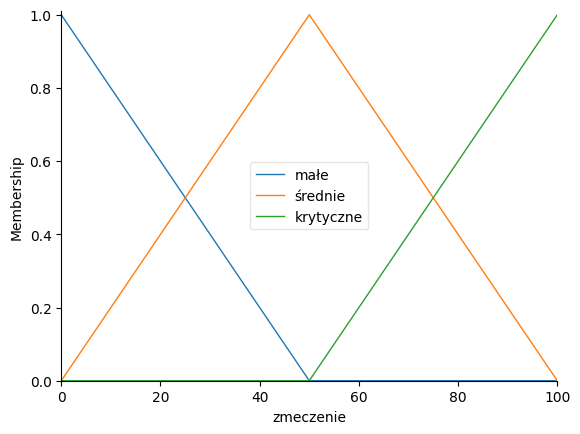

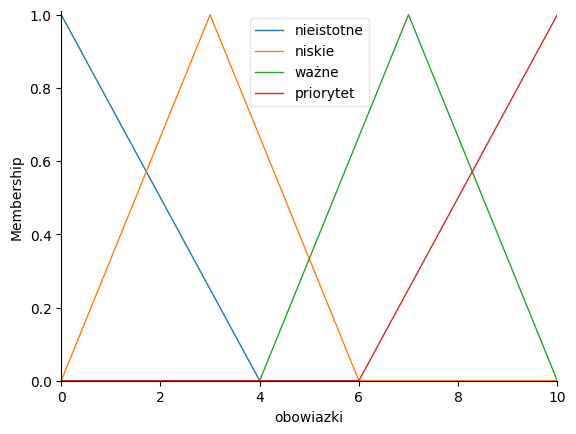

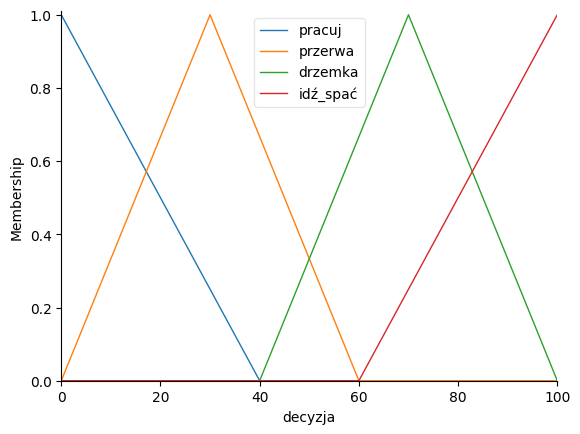

In [5]:
# Funkcje przynależności
# Wejście: Zmęczenie
zmeczenie['małe'] = fuzzy.trimf(zmeczenie.universe, [0, 0, 50])
zmeczenie['średnie'] = fuzzy.trimf(zmeczenie.universe, [0, 50, 100])
zmeczenie['krytyczne'] = fuzzy.trimf(zmeczenie.universe, [50, 100, 100])
zmeczenie.view()

# Wejście: Ważność obowiązków
obowiazki['nieistotne'] = fuzzy.trimf(obowiazki.universe, [0, 0, 4])
obowiazki['niskie'] = fuzzy.trimf(obowiazki.universe, [0, 3, 6])
obowiazki['ważne'] = fuzzy.trimf(obowiazki.universe, [4, 7, 10])
obowiazki['priorytet'] = fuzzy.trimf(obowiazki.universe, [6, 10, 10])
obowiazki.view()

# Wyjście: Decyzja
decyzja['pracuj'] = fuzzy.trimf(decyzja.universe, [0, 0, 40])
decyzja['przerwa'] = fuzzy.trimf(decyzja.universe, [0, 30, 60])
decyzja['drzemka'] = fuzzy.trimf(decyzja.universe, [40, 70, 100])
decyzja['idź_spać'] = fuzzy.trimf(decyzja.universe, [60, 100, 100])
decyzja.view()
plt.show()

### Baza reguł
Określamy reguły logiczne wiążące ze sobą zmienne wejściowe, które system wykorzystuje we wnioskowaniu.  

Przykładowo:  
JEŻELI zmęczenie jest małe I obowiązki są nieistotne WTEDY decyzja to przerwa (można odpocząć, bo praca nie jest bardzo ważna).

JEŻELI zmęczenie jest małe I obowiązki są priorytet WTEDY decyzja to pracuj.

JEŻELI zmęczenie jest średnie I obowiązki są wazne WTEDY decyzja to drzemka (kompromis).

JEŻELI zmęczenie jest krytyczne I obowiązki są priorytet WTEDY decyzja to drzemka (organizm jest zbyt zmęczony na efektywną pracę, ale zadania są zbyt ważne, by całkowicie zasnąć).

JEŻELI zmęczenie jest krytyczne I obowiązki są niskie WTEDY decyzja to idź_spać.

In [6]:
# Pełna baza reguł 
rules = [
    # Dla małego zmęczenia
    ctrl.Rule(zmeczenie['małe'] & obowiazki['nieistotne'], decyzja['przerwa']),
    ctrl.Rule(zmeczenie['małe'] & obowiazki['niskie'], decyzja['pracuj']),
    ctrl.Rule(zmeczenie['małe'] & obowiazki['ważne'], decyzja['pracuj']),
    ctrl.Rule(zmeczenie['małe'] & obowiazki['priorytet'], decyzja['pracuj']),
    
    # Dla średniego zmęczenia
    ctrl.Rule(zmeczenie['średnie'] & obowiazki['nieistotne'], decyzja['przerwa']),
    ctrl.Rule(zmeczenie['średnie'] & obowiazki['niskie'], decyzja['przerwa']),
    ctrl.Rule(zmeczenie['średnie'] & obowiazki['ważne'], decyzja['drzemka']),
    ctrl.Rule(zmeczenie['średnie'] & obowiazki['priorytet'], decyzja['przerwa']),
    
    # Dla krytycznego zmęczenia
    ctrl.Rule(zmeczenie['krytyczne'] & obowiazki['nieistotne'], decyzja['idź_spać']),
    ctrl.Rule(zmeczenie['krytyczne'] & obowiazki['niskie'], decyzja['idź_spać']),
    ctrl.Rule(zmeczenie['krytyczne'] & obowiazki['ważne'], decyzja['drzemka']),
    ctrl.Rule(zmeczenie['krytyczne'] & obowiazki['priorytet'], decyzja['drzemka'])
]

### Metoda dyfuzyfikacji
Do wyznaczenia wartości wyjściowej zastosowano metodę środka ciężkości (centroid). Jest to najczęściej stosowana metoda, która wylicza wypadkową wartość na podstawie pola powierzchni pod zagregowaną funkcją przynależności wszystkich aktywnych reguł.

### Symulacja i przykład fazy wnioskowania


Wynik decyzyjny: 56.11%


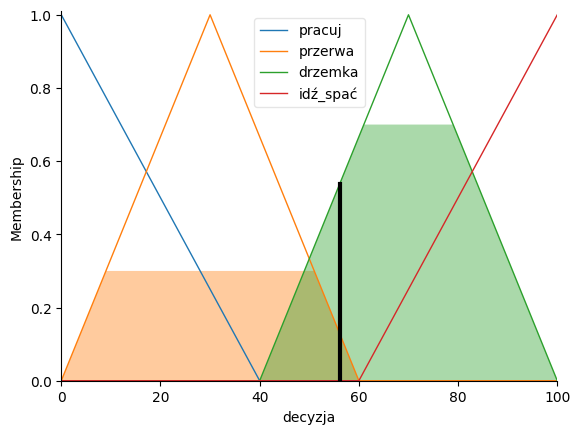

In [7]:
# Symulacja
sleep_ctrl = ctrl.ControlSystem(rules)
sleep_sim = ctrl.ControlSystemSimulation(sleep_ctrl)

# TEST: Jestem bardzo zmęczony (85%), ale mam ważne zadania (9/10)
sleep_sim.input['zmeczenie'] = 85
sleep_sim.input['obowiazki'] = 9
sleep_sim.compute()

print(f"Wynik decyzyjny: {sleep_sim.output['decyzja']:.2f}%")
decyzja.view(sim=sleep_sim)

### Wykres powierzchni decyzyjnej

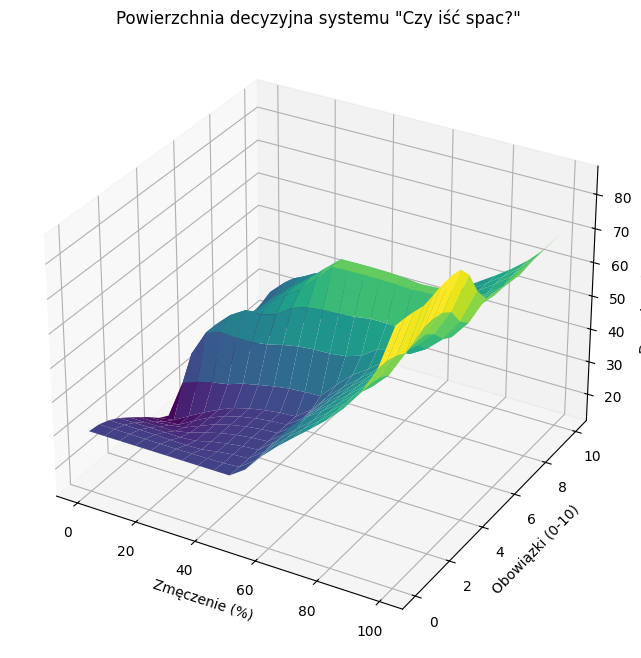

In [8]:
# Generowanie powierzchni decyzyjnej
x, y = np.meshgrid(np.linspace(0, 100, 20), np.linspace(0, 10, 20))
z = np.zeros_like(x)

for i in range(20):
    for j in range(20):
        sleep_sim.input['zmeczenie'] = x[i, j]
        sleep_sim.input['obowiazki'] = y[i, j]
        sleep_sim.compute()
        z[i, j] = sleep_sim.output['decyzja']

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, cmap='viridis')
ax.set_xlabel('Zmęczenie (%)')
ax.set_ylabel('Obowiązki (0-10)')
ax.set_zlabel('Decyzja o śnie (%)')
plt.title('Powierzchnia decyzyjna systemu "Czy iść spac?"')
plt.show()

### Wnioski

Rozbudowanie bazy do 12 reguł pozwoliło na precyzyjne pokrycie całej dziedziny wejściowej. System poprawnie reaguje na sytuacje konfliktowe, takie jak wysokie zmęczenie przy jednoczesnym wysokim priorytecie zadań, sugerując wówczas kompromisową drzemkę zamiast skrajnej pracy lub długiego snu.  

Analiza funkcji przynależności: Zastosowanie funkcji trójkątnych (trimf) z odpowiednim stopniem nachodzenia na siebie (ang. overlap) zapewniło płynność działania systemu. Brak gwałtownych skoków na wykresie powierzchni decyzyjnej potwierdza, że system jest stabilny i poprawnie skonfigurowany.  

Proces defuzyfikacji: Wybór metody środka ciężkości (ang. centroid) okazał się optymalny dla tego problemu, ponieważ uwzględnia on wpływ wszystkich aktywnych reguł jednocześnie, co pozwala na uzyskanie najbardziej zrównoważonej odpowiedzi systemu.  

Wybór większej liczby zmiennych lingwistycznych na wyjściu był „bez-kosztowy” i pozwolił na lepsze dopasowanie porady systemu bez nadmiernego komplikowania obliczeń.